In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import glob

sns.set_style('whitegrid')

from river.forest import ARFClassifier

import matplotlib
# set font size to 16
matplotlib.rcParams.update({'font.size': 16})

ROOT = "./CIC2019/"
SEED = 0 

In [2]:
files_cic2019 = glob.glob(ROOT + "03-11/*.csv")
files_cic2019.sort()
files_cic2019

['./CIC2019/03-11/01_Portmap.csv',
 './CIC2019/03-11/03_LDAP.csv',
 './CIC2019/03-11/04_MSSQL.csv',
 './CIC2019/03-11/05_UDP.csv',
 './CIC2019/03-11/06_UDPLag.csv',
 './CIC2019/03-11/07_Syn.csv']

In [3]:
dfs = []
for task_id, file in enumerate(tqdm(files_cic2019)):
    df = pd.read_csv(file, engine='pyarrow')
    df.columns = df.columns.str.strip()
    benign_df = df[df['Label'] == 'BENIGN']
    if len(benign_df) > 5000:
        benign_df = benign_df.sample(n=5000, random_state=SEED)
    malicious_df = df[df['Label'] != 'BENIGN']
    malicous_sampled_df = malicious_df.sample(n=2*len(benign_df), random_state=SEED)
    undersampled_df = pd.concat([malicous_sampled_df, benign_df])
    undersampled_df["task_id"] = task_id
    dfs.append(undersampled_df)
df = pd.concat(dfs)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:26<00:00,  4.50s/it]


In [4]:
df = df.drop(columns=['Unnamed: 0', 'Flow ID', 'Source IP', 'Destination IP', 'Protocol', 'Source Port', 'Destination Port', 'Timestamp', 'SimillarHTTP', 'Inbound'])

In [5]:
# replace NaNs and infinity with -1
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(-1)

In [6]:
# define train set and test set for each task
X_train_tasks = []
X_test_tasks = []
y_train_tasks = []
y_test_tasks = []
for i in range(len(files_cic2019)):
    X_task = df[df["task_id"] == i].drop(["Label", "task_id"], axis=1).to_numpy()
    y_task = df[df["task_id"] == i]["Label"].to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(X_task, y_task, test_size=0.2, random_state=SEED, stratify=y_task)
    X_train_tasks.append(X_train)
    X_test_tasks.append(X_test)
    y_train_tasks.append(y_train)
    y_test_tasks.append(y_test)

In [7]:
model = ARFClassifier()
avg_task_f1_scores = []
task_f1_scores = []
for task_id in range(len(files_cic2019)):
    X_train_task, y_train_task = X_train_tasks[task_id], y_train_tasks[task_id]

    # learn on current task
    for i in tqdm(range(len(X_train_task))):
        model.learn_one(dict(enumerate(X_train_task[i].flatten(), 1)), y_train_task[i])

    # compute average f1-score on current task and past tasks
    f1_scores = []
    for past_id in range(task_id + 1):
        X_test_task, y_test_task = X_test_tasks[past_id], y_test_tasks[past_id]
        y_pred = []
        for j in range(len(X_test_task)):
            y_pred.append(model.predict_one(dict(enumerate(X_test_task[j].flatten(), 1))))
        f1_scores.append(accuracy_score(y_test_task, y_pred))
    task_f1_scores.append(f1_scores[-1])
    avg_task_f1_scores.append(np.mean(f1_scores))

100%|██████████| 12000/12000 [00:09<00:00, 1301.31it/s]


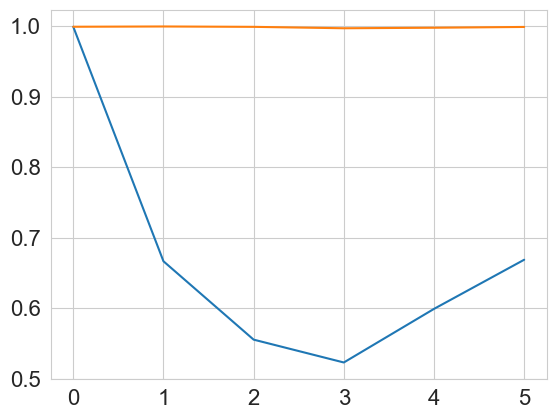

In [8]:
plt.plot(avg_task_f1_scores);
plt.plot(task_f1_scores);

In [9]:
print(avg_task_f1_scores)

[0.9989440337909187, 0.6663333333333333, 0.5551580202742993, 0.5227565172485613, 0.5987641132426488, 0.6684751099194214]


In [10]:
print(task_f1_scores)

[0.9989440337909187, 0.9993333333333333, 0.9988073941562313, 0.9968102073365231, 0.9975419909873003, 0.9986666666666667]
